Abfrage im OHsome Dashboard:

"""
highway=path and bicycle=designated
or
highway=cycleway
or
cycleway=lane
or
cycleway:right=lane
or
cycleway:left=lane
or
cycleway:both=lane
or
cycleway=track
or
cycleway:right=track
or
cycleway:left=track
or
cycleway:both=track
"""

https://dashboard.ohsome.org/de/#backend=ohsomeApi&groupBy=none&time=2020-01-01T00%3A00%3A00Z%2F2025-10-01T12%3A00Z%2FP1M&measure=length&filter=highway%3Dpath+and+bicycle%3Ddesignated%0Aor%0Ahighway%3Dcycleway%0Aor%0Acycleway%3Dlane%0Aor%0Acycleway%3Aright%3Dlane%0Aor%0Acycleway%3Aleft%3Dlane%0Aor%0Acycleway%3Aboth%3Dlane%0Aor%0Acycleway%3Dtrack%0Aor%0Acycleway%3Aright%3Dtrack%0Aor%0Acycleway%3Aleft%3Dtrack%0Aor%0Acycleway%3Aboth%3Dtrack&adminids=-51477

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

# Read the CSV data from the previous cell
csv_data = """timestamp,value
2020-01-01T00:00:00Z,94682535.09
2020-02-01T00:00:00Z,94811380.67
2020-03-01T00:00:00Z,94959221.44
2020-04-01T00:00:00Z,95080412.43
2020-05-01T00:00:00Z,95185507.26
2020-06-01T00:00:00Z,95401880.03
2020-07-01T00:00:00Z,95589725.64
2020-08-01T00:00:00Z,95802029.03
2020-09-01T00:00:00Z,95955024.5
2020-10-01T00:00:00Z,96076797.77
2020-11-01T00:00:00Z,96154306.34
2020-12-01T00:00:00Z,96316409.87
2021-01-01T00:00:00Z,96548447.73
2021-02-01T00:00:00Z,96649348.76
2021-03-01T00:00:00Z,96755787.34
2021-04-01T00:00:00Z,96813354.73
2021-05-01T00:00:00Z,96850553.59
2021-06-01T00:00:00Z,96994505.57
2021-07-01T00:00:00Z,97040743.08
2021-08-01T00:00:00Z,97181067.9
2021-09-01T00:00:00Z,97373255.06
2021-10-01T00:00:00Z,97456757.49
2021-11-01T00:00:00Z,97641842.21
2021-12-01T00:00:00Z,97770275.7
2022-01-01T00:00:00Z,97847727.97
2022-02-01T00:00:00Z,97970183.64
2022-03-01T00:00:00Z,98021915.75
2022-04-01T00:00:00Z,98052184.88
2022-05-01T00:00:00Z,98166493.55
2022-06-01T00:00:00Z,98205696.98
2022-07-01T00:00:00Z,98353987.97
2022-08-01T00:00:00Z,98478575.9
2022-09-01T00:00:00Z,98502233.61
2022-10-01T00:00:00Z,98651297.09
2022-11-01T00:00:00Z,98771419.69
2022-12-01T00:00:00Z,98900610.56
2023-01-01T00:00:00Z,99047044.11
2023-02-01T00:00:00Z,99083461.96
2023-03-01T00:00:00Z,99106876.41
2023-04-01T00:00:00Z,99204027.83
2023-05-01T00:00:00Z,99339490.82
2023-06-01T00:00:00Z,99474512.9
2023-07-01T00:00:00Z,99555609.46
2023-08-01T00:00:00Z,99672932.25
2023-09-01T00:00:00Z,99848410.35
2023-10-01T00:00:00Z,99944902.34
2023-11-01T00:00:00Z,100212007.08
2023-12-01T00:00:00Z,100258213.42
2024-01-01T00:00:00Z,100427741.74
2024-02-01T00:00:00Z,100496939.93
2024-03-01T00:00:00Z,100659780.6
2024-04-01T00:00:00Z,100750061.35
2024-05-01T00:00:00Z,100815817.75
2024-06-01T00:00:00Z,101027002.46
2024-07-01T00:00:00Z,101042558.28
2024-08-01T00:00:00Z,101113571.5
2024-09-01T00:00:00Z,101169372.92
2024-10-01T00:00:00Z,101206219.54
2024-11-01T00:00:00Z,101356502.44
2024-12-01T00:00:00Z,101428056.61
2025-01-01T00:00:00Z,101493498.79
2025-02-01T00:00:00Z,101536973.8
2025-03-01T00:00:00Z,101580477.48
2025-04-01T00:00:00Z,101671066.51
2025-05-01T00:00:00Z,101799795.15
2025-06-01T00:00:00Z,101885527.75
2025-07-01T00:00:00Z,102064106.82
2025-08-01T00:00:00Z,102228193.64
2025-09-01T00:00:00Z,102459552.81
2025-10-01T00:00:00Z,102680537.91
2025-11-01T00:00:00Z,102901004.17
2025-12-01T00:00:00Z,103028815.49
2026-01-01T00:00:00Z,103301074.15
"""

# Read CSV data into DataFrame
df = pd.read_csv(StringIO(csv_data))

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Calculate relative increase per month (percentage change from previous month)
df['relative_increase'] = df['value'].pct_change() * 100

# Display the DataFrame
print("DataFrame with relative increase per month:")
print(df.head(10))
print("\n...")
print(df.tail(10))


DataFrame with relative increase per month:
                  timestamp        value  relative_increase
0 2020-01-01 00:00:00+00:00  94682535.09                NaN
1 2020-02-01 00:00:00+00:00  94811380.67           0.136082
2 2020-03-01 00:00:00+00:00  94959221.44           0.155931
3 2020-04-01 00:00:00+00:00  95080412.43           0.127624
4 2020-05-01 00:00:00+00:00  95185507.26           0.110533
5 2020-06-01 00:00:00+00:00  95401880.03           0.227317
6 2020-07-01 00:00:00+00:00  95589725.64           0.196899
7 2020-08-01 00:00:00+00:00  95802029.03           0.222099
8 2020-09-01 00:00:00+00:00  95955024.50           0.159700
9 2020-10-01 00:00:00+00:00  96076797.77           0.126907

...
                   timestamp         value  relative_increase
63 2025-04-01 00:00:00+00:00  1.016711e+08           0.089180
64 2025-05-01 00:00:00+00:00  1.017998e+08           0.126613
65 2025-06-01 00:00:00+00:00  1.018855e+08           0.084217
66 2025-07-01 00:00:00+00:00  1.020641e+08 

Average monthly increase: 0.1211%
Maximum monthly increase: 0.2673%
Minimum monthly increase: 0.0154%


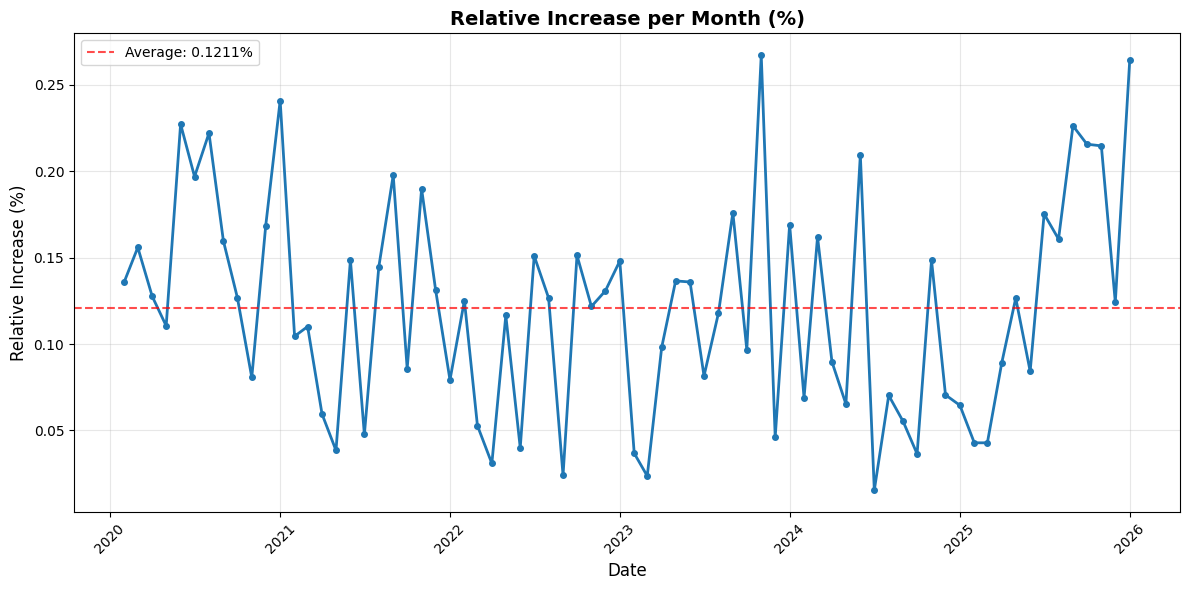

In [2]:
# Create the plot
plt.figure(figsize=(12, 6))

# Plot the relative increase per month
plt.plot(df['timestamp'][1:], df['relative_increase'][1:], marker='o', linewidth=2, markersize=4)

# Customize the plot
plt.title('Relative Increase per Month (%)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Relative Increase (%)', fontsize=12)
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add some statistics
mean_increase = df['relative_increase'][1:].mean()
print(f"Average monthly increase: {mean_increase:.4f}%")
print(f"Maximum monthly increase: {df['relative_increase'][1:].max():.4f}%")
print(f"Minimum monthly increase: {df['relative_increase'][1:].min():.4f}%")

# Add horizontal line for average
plt.axhline(y=mean_increase, color='red', linestyle='--', alpha=0.7, label=f'Average: {mean_increase:.4f}%')
plt.legend()

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()


Absolute Increase Statistics:
Average monthly absolute increase: 119,701.93
Maximum monthly absolute increase: 272,258.66
Minimum monthly absolute increase: 15,555.82
Total increase over period: 8,618,539.06


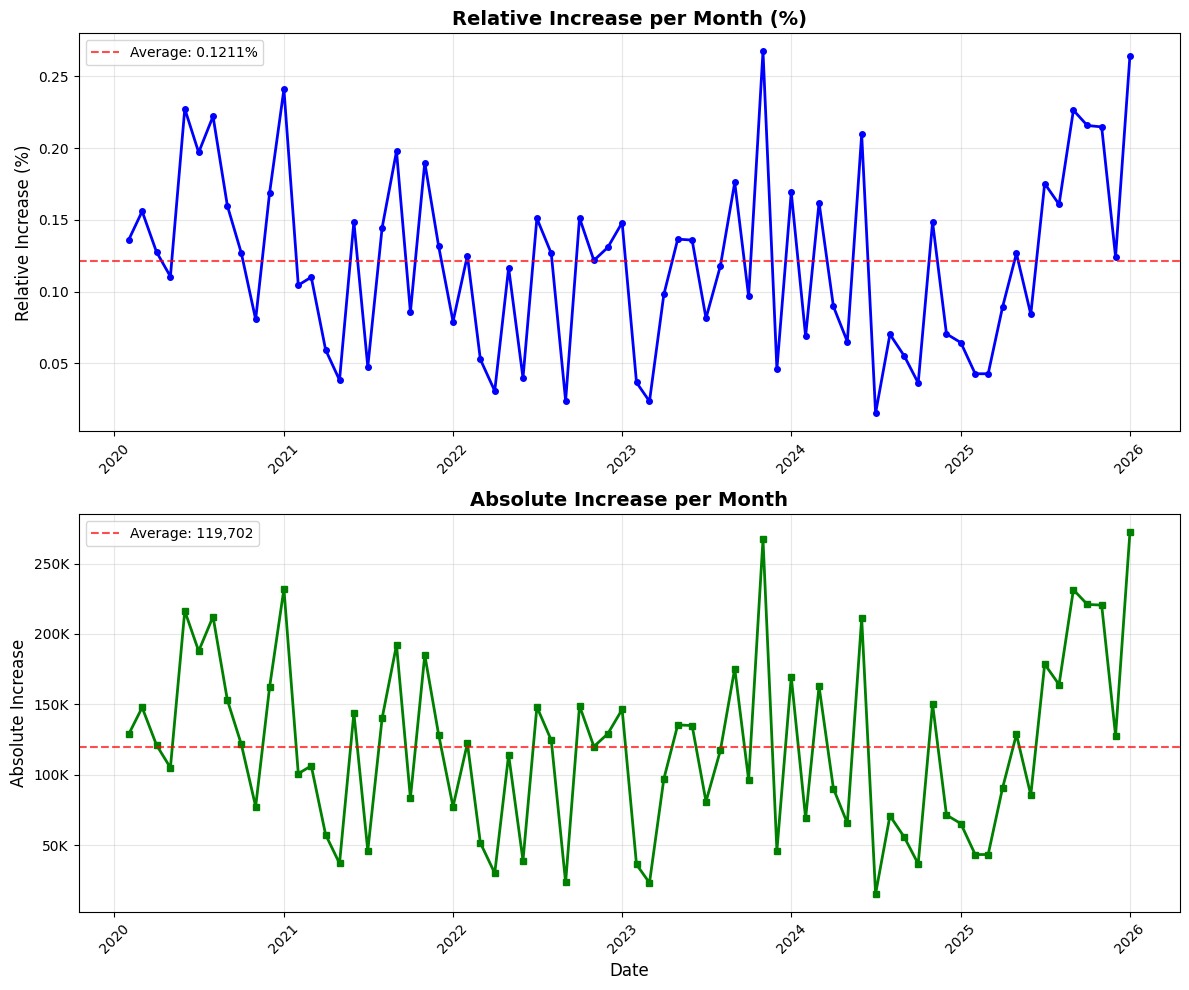

In [3]:
# Calculate absolute increase per month
df['absolute_increase'] = df['value'].diff()

# Display statistics for absolute increase
print("Absolute Increase Statistics:")
print(f"Average monthly absolute increase: {df['absolute_increase'][1:].mean():,.2f}")
print(f"Maximum monthly absolute increase: {df['absolute_increase'][1:].max():,.2f}")
print(f"Minimum monthly absolute increase: {df['absolute_increase'][1:].min():,.2f}")
print(f"Total increase over period: {df['value'].iloc[-1] - df['value'].iloc[0]:,.2f}")

# Create a subplot with both relative and absolute increases
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Relative increase per month
ax1.plot(df['timestamp'][1:], df['relative_increase'][1:], marker='o', linewidth=2, markersize=4, color='blue')
ax1.set_title('Relative Increase per Month (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Relative Increase (%)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Add average line for relative increase
mean_relative = df['relative_increase'][1:].mean()
ax1.axhline(y=mean_relative, color='red', linestyle='--', alpha=0.7, label=f'Average: {mean_relative:.4f}%')
ax1.legend()

# Plot 2: Absolute increase per month
ax2.plot(df['timestamp'][1:], df['absolute_increase'][1:], marker='s', linewidth=2, markersize=4, color='green')
ax2.set_title('Absolute Increase per Month', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Absolute Increase', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Add average line for absolute increase
mean_absolute = df['absolute_increase'][1:].mean()
ax2.axhline(y=mean_absolute, color='red', linestyle='--', alpha=0.7, label=f'Average: {mean_absolute:,.0f}')
ax2.legend()

# Format y-axis for absolute increase to show values in thousands/millions
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()


In [4]:
# Read the CSV data from the previous cell
csv_data = """timestamp,value
2011-01-01T00:00:00Z,64224831.97
2011-02-01T00:00:00Z,64542789.34
2011-03-01T00:00:00Z,64930688.64
2011-04-01T00:00:00Z,65563913.94
2011-05-01T00:00:00Z,66325814.26
2011-06-01T00:00:00Z,67102375.34
2011-07-01T00:00:00Z,67762758.17
2011-08-01T00:00:00Z,68302247.58
2011-09-01T00:00:00Z,69033137.5
2011-10-01T00:00:00Z,69476768.68
2011-11-01T00:00:00Z,70375502.98
2011-12-01T00:00:00Z,70703090.29
2012-01-01T00:00:00Z,70682930.33
2012-02-01T00:00:00Z,70944090.92
2012-03-01T00:00:00Z,71246750.7
2012-04-01T00:00:00Z,71757122.25
2012-05-01T00:00:00Z,72221556.18
2012-06-01T00:00:00Z,72754760.97
2012-07-01T00:00:00Z,73146330.72
2012-08-01T00:00:00Z,72915358.16
2012-09-01T00:00:00Z,73456684.72
2012-10-01T00:00:00Z,74118162.71
2012-11-01T00:00:00Z,74579473.3
2012-12-01T00:00:00Z,74927244.06
2013-01-01T00:00:00Z,75437425.37
2013-02-01T00:00:00Z,75936218.51
2013-03-01T00:00:00Z,76308062.09
2013-04-01T00:00:00Z,76725435.33
2013-05-01T00:00:00Z,77129767.79
2013-06-01T00:00:00Z,77755792.68
2013-07-01T00:00:00Z,78376925.57
2013-08-01T00:00:00Z,79049963.61
2013-09-01T00:00:00Z,79637175.48
2013-10-01T00:00:00Z,79962024.37
2013-11-01T00:00:00Z,80436514.58
2013-12-01T00:00:00Z,81118904.93
2014-01-01T00:00:00Z,81469944.7
2014-02-01T00:00:00Z,81609256.98
2014-03-01T00:00:00Z,81941846.2
2014-04-01T00:00:00Z,82256370.87
2014-05-01T00:00:00Z,82494253.77
2014-06-01T00:00:00Z,82962822.28
2014-07-01T00:00:00Z,83565328.08
2014-08-01T00:00:00Z,83886625.03
2014-09-01T00:00:00Z,84123257.51
2014-10-01T00:00:00Z,84125141.61
2014-11-01T00:00:00Z,84356607.59
2014-12-01T00:00:00Z,84636071.72
2015-01-01T00:00:00Z,84802576.64
2015-02-01T00:00:00Z,84968669.37
2015-03-01T00:00:00Z,85055263.61
2015-04-01T00:00:00Z,85298386.51
2015-05-01T00:00:00Z,85591961.93
2015-06-01T00:00:00Z,86048161.12
2015-07-01T00:00:00Z,86400640.2
2015-08-01T00:00:00Z,86980589.58
2015-09-01T00:00:00Z,87249423.85
2015-10-01T00:00:00Z,87485630.05
2015-11-01T00:00:00Z,87731678.9
2015-12-01T00:00:00Z,87881816.74
2016-01-01T00:00:00Z,88098506.42
2016-02-01T00:00:00Z,88091416.06
2016-03-01T00:00:00Z,88259620.88
2016-04-01T00:00:00Z,88368100.8
2016-05-01T00:00:00Z,88396689.89
2016-06-01T00:00:00Z,88626684.67
2016-07-01T00:00:00Z,88765877.67
2016-08-01T00:00:00Z,89015957.97
2016-09-01T00:00:00Z,89308114.09
2016-10-01T00:00:00Z,89403337.9
2016-11-01T00:00:00Z,89241953.09
2016-12-01T00:00:00Z,89414175.63
2017-01-01T00:00:00Z,89536789.98
2017-02-01T00:00:00Z,89714734.61
2017-03-01T00:00:00Z,89859565.47
2017-04-01T00:00:00Z,90005907.29
2017-05-01T00:00:00Z,90166975.09
2017-06-01T00:00:00Z,90416573.89
2017-07-01T00:00:00Z,90704680.25
2017-08-01T00:00:00Z,90847384.16
2017-09-01T00:00:00Z,90879898.49
2017-10-01T00:00:00Z,91044866.19
2017-11-01T00:00:00Z,91158162.92
2017-12-01T00:00:00Z,91304320.68
2018-01-01T00:00:00Z,91418386.95
2018-02-01T00:00:00Z,91518841.13
2018-03-01T00:00:00Z,91626370.83
2018-04-01T00:00:00Z,91755026.2
2018-05-01T00:00:00Z,91912345.29
2018-06-01T00:00:00Z,92122078.32
2018-07-01T00:00:00Z,92166606.42
2018-08-01T00:00:00Z,92316439.23
2018-09-01T00:00:00Z,92519970.9
2018-10-01T00:00:00Z,92699760
2018-11-01T00:00:00Z,92810512.37
2018-12-01T00:00:00Z,92958490.53
2019-01-01T00:00:00Z,93150842.8
2019-02-01T00:00:00Z,93248224.91
2019-03-01T00:00:00Z,93354664.17
2019-04-01T00:00:00Z,93462774.16
2019-05-01T00:00:00Z,93515606.5
2019-06-01T00:00:00Z,93702817.7
2019-07-01T00:00:00Z,93879364.61
2019-08-01T00:00:00Z,94056781.04
2019-09-01T00:00:00Z,94296990.93
2019-10-01T00:00:00Z,94408437.95
2019-11-01T00:00:00Z,94512808.68
2019-12-01T00:00:00Z,94471112.94
2020-01-01T00:00:00Z,94682535.09
2020-02-01T00:00:00Z,94811380.67
2020-03-01T00:00:00Z,94959221.44
2020-04-01T00:00:00Z,95080412.43
2020-05-01T00:00:00Z,95185507.26
2020-06-01T00:00:00Z,95401880.03
2020-07-01T00:00:00Z,95589725.64
2020-08-01T00:00:00Z,95802029.03
2020-09-01T00:00:00Z,95955024.5
2020-10-01T00:00:00Z,96076797.77
2020-11-01T00:00:00Z,96154306.34
2020-12-01T00:00:00Z,96316409.87
2021-01-01T00:00:00Z,96548447.73
2021-02-01T00:00:00Z,96649348.76
2021-03-01T00:00:00Z,96755787.34
2021-04-01T00:00:00Z,96813354.73
2021-05-01T00:00:00Z,96850553.59
2021-06-01T00:00:00Z,96994505.57
2021-07-01T00:00:00Z,97040743.08
2021-08-01T00:00:00Z,97181067.9
2021-09-01T00:00:00Z,97373255.06
2021-10-01T00:00:00Z,97456757.49
2021-11-01T00:00:00Z,97641842.21
2021-12-01T00:00:00Z,97770275.7
2022-01-01T00:00:00Z,97847727.97
2022-02-01T00:00:00Z,97970183.64
2022-03-01T00:00:00Z,98021915.75
2022-04-01T00:00:00Z,98052184.88
2022-05-01T00:00:00Z,98166493.55
2022-06-01T00:00:00Z,98205696.98
2022-07-01T00:00:00Z,98353987.97
2022-08-01T00:00:00Z,98478575.9
2022-09-01T00:00:00Z,98502233.61
2022-10-01T00:00:00Z,98651297.09
2022-11-01T00:00:00Z,98771419.69
2022-12-01T00:00:00Z,98900610.56
2023-01-01T00:00:00Z,99047044.11
2023-02-01T00:00:00Z,99083461.96
2023-03-01T00:00:00Z,99106876.41
2023-04-01T00:00:00Z,99204027.83
2023-05-01T00:00:00Z,99339490.82
2023-06-01T00:00:00Z,99474512.9
2023-07-01T00:00:00Z,99555609.46
2023-08-01T00:00:00Z,99672932.25
2023-09-01T00:00:00Z,99848410.35
2023-10-01T00:00:00Z,99944902.34
2023-11-01T00:00:00Z,100212007.08
2023-12-01T00:00:00Z,100258213.42
2024-01-01T00:00:00Z,100427741.74
2024-02-01T00:00:00Z,100496939.93
2024-03-01T00:00:00Z,100659780.6
2024-04-01T00:00:00Z,100750061.35
2024-05-01T00:00:00Z,100815817.75
2024-06-01T00:00:00Z,101027002.46
2024-07-01T00:00:00Z,101042558.28
2024-08-01T00:00:00Z,101113571.5
2024-09-01T00:00:00Z,101169372.92
2024-10-01T00:00:00Z,101206219.54
2024-11-01T00:00:00Z,101356502.44
2024-12-01T00:00:00Z,101428056.61
2025-01-01T00:00:00Z,101493498.79
2025-02-01T00:00:00Z,101536973.8
2025-03-01T00:00:00Z,101580477.48
2025-04-01T00:00:00Z,101671066.51
2025-05-01T00:00:00Z,101799795.15
2025-06-01T00:00:00Z,101885527.75
2025-07-01T00:00:00Z,102064106.82
2025-08-01T00:00:00Z,102228193.64
2025-09-01T00:00:00Z,102459552.81
2025-10-01T00:00:00Z,102680537.91
2025-11-01T00:00:00Z,102901004.17
2025-12-01T00:00:00Z,103028815.49
2026-01-01T00:00:00Z,103301074.15
"""

# Read CSV data into DataFrame
df = pd.read_csv(StringIO(csv_data))

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Calculate relative increase per month (percentage change from previous month)
df['relative_increase'] = df['value'].pct_change() * 100

# Display the DataFrame
print("DataFrame with relative increase per month:")
print(df.head(10))
print("\n...")
print(df.tail(10))


DataFrame with relative increase per month:
                  timestamp        value  relative_increase
0 2011-01-01 00:00:00+00:00  64224831.97                NaN
1 2011-02-01 00:00:00+00:00  64542789.34           0.495069
2 2011-03-01 00:00:00+00:00  64930688.64           0.600996
3 2011-04-01 00:00:00+00:00  65563913.94           0.975233
4 2011-05-01 00:00:00+00:00  66325814.26           1.162073
5 2011-06-01 00:00:00+00:00  67102375.34           1.170828
6 2011-07-01 00:00:00+00:00  67762758.17           0.984142
7 2011-08-01 00:00:00+00:00  68302247.58           0.796144
8 2011-09-01 00:00:00+00:00  69033137.50           1.070082
9 2011-10-01 00:00:00+00:00  69476768.68           0.642635

...
                    timestamp         value  relative_increase
171 2025-04-01 00:00:00+00:00  1.016711e+08           0.089180
172 2025-05-01 00:00:00+00:00  1.017998e+08           0.126613
173 2025-06-01 00:00:00+00:00  1.018855e+08           0.084217
174 2025-07-01 00:00:00+00:00  1.020641

Yearly Average Statistics:
    year  relative_increase  absolute_increase
0   2011           0.877842      588932.574545
1   2012           0.485292      352012.814167
2   2013           0.663952      515971.739167
3   2014           0.354484      293097.232500
4   2015           0.314213      270478.751667
5   2016           0.144250      127696.574167
6   2017           0.174499      157512.087500
7   2018           0.149748      137847.487500
8   2019           0.134629      126051.867500
9   2020           0.161346      153774.744167
10  2021           0.124945      121155.485833
11  2022           0.095846       94194.571667
12  2023           0.113698      113133.571667
13  2024           0.096736       97486.932500
14  2025           0.130597      133396.573333
15  2026           0.264255      272258.660000


/tmp/ipykernel_505710/1087224843.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_505710/1087224843.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


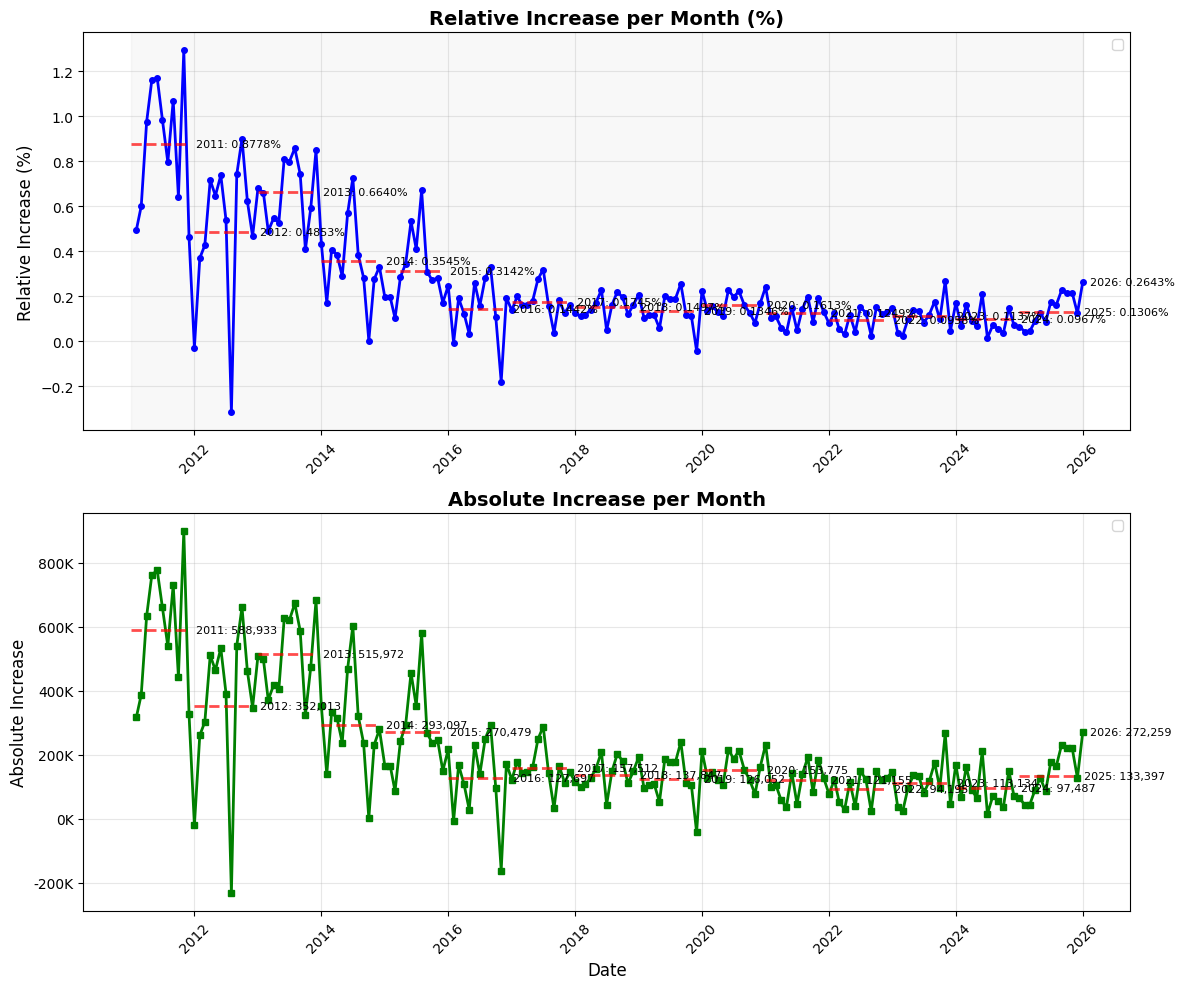

In [5]:
# Calculate absolute increase per month
df['absolute_increase'] = df['value'].diff()
df['year'] = df['timestamp'].dt.year

# Calculate yearly averages for relative and absolute increases
yearly_stats = df.groupby('year').agg({
    'relative_increase': 'mean',
    'absolute_increase': 'mean'
}).reset_index()

print("Yearly Average Statistics:")
print(yearly_stats)

# Create a subplot with both relative and absolute increases
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Relative increase per month
ax1.plot(df['timestamp'][1:], df['relative_increase'][1:], marker='o', linewidth=2, markersize=4, color='blue')
ax1.set_title('Relative Increase per Month (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Relative Increase (%)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Add yearly average lines for relative increase
ax1.axvspan(df['timestamp'].iloc[0], df['timestamp'].iloc[-1], alpha=0.05, color='gray')  # Background
for _, row in yearly_stats.iterrows():
    year = int(row['year'])  # Convert to int
    year_mean = row['relative_increase']
    
    # Find the start and end dates for this year in the data
    year_data = df[df['year'] == year]
    if len(year_data) > 0:
        year_start_date = year_data['timestamp'].iloc[0]
        year_end_date = year_data['timestamp'].iloc[-1]
        
        # Plot horizontal line only for this year's data
        ax1.plot([year_start_date, year_end_date], [year_mean, year_mean], 
                 color='red', linestyle='--', alpha=0.7, linewidth=2)
        
        # Add label at the end of the year
        ax1.text(year_end_date, year_mean, f'  {year}: {year_mean:.4f}%', 
                 verticalalignment='center', fontsize=8)

ax1.legend()

# Plot 2: Absolute increase per month
ax2.plot(df['timestamp'][1:], df['absolute_increase'][1:], marker='s', linewidth=2, markersize=4, color='green')
ax2.set_title('Absolute Increase per Month', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Absolute Increase', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Add yearly average lines for absolute increase
for _, row in yearly_stats.iterrows():
    year = int(row['year'])  # Convert to int
    year_mean = row['absolute_increase']
    
    # Find the start and end dates for this year in the data
    year_data = df[df['year'] == year]
    if len(year_data) > 0:
        year_start_date = year_data['timestamp'].iloc[0]
        year_end_date = year_data['timestamp'].iloc[-1]
        
        # Plot horizontal line only for this year's data
        ax2.plot([year_start_date, year_end_date], [year_mean, year_mean], 
                 color='red', linestyle='--', alpha=0.7, linewidth=2)
        
        # Add label at the end of the year
        ax2.text(year_end_date, year_mean, f'  {year}: {year_mean:,.0f}', 
                 verticalalignment='center', fontsize=8)

ax2.legend()

# Format y-axis for absolute increase to show values in thousands/millions
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()
